In [58]:
# CELL 1: IMPORTS AND SETUP
# ============================================================================

import pandas as pd
import numpy as np
import requests
import os
import time
import random
import json
import hashlib
import faiss
import pickle
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Union
from dataclasses import dataclass, asdict
from enum import Enum
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# API clients
try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True
    print("✅ OpenAI library available")
except ImportError:
    print("❌ OpenAI not installed. Install with: pip install openai")
    OPENAI_AVAILABLE = False

try:
    from groq import Groq
    GROQ_AVAILABLE = True
    print("✅ Groq library available")
except ImportError:
    print("❌ Groq not installed. Install with: pip install groq")
    GROQ_AVAILABLE = False

# Optional: LangSmith for observability
try:
    from langsmith import Client, traceable
    LANGSMITH_AVAILABLE = True
    print("✅ LangSmith available (optional)")
except ImportError:
    LANGSMITH_AVAILABLE = False
    print("📝 LangSmith not available (optional - install with: pip install langsmith)")

# Load environment variables
try:
    from dotenv import load_dotenv
    load_dotenv()
    print("✅ Environment variables loaded")
except ImportError:
    print("📝 python-dotenv not found. Set environment variables manually.")

# Configure display and warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 20)
plt.style.use('default')
sns.set_palette("husl")

print("\n" + "="*60)
print("🚀 SIMPLIFIED HYBRID BEAUTY PRODUCT CLASSIFIER")
print("="*60)
print("📊 Pure hybrid approach with configurable threshold")

✅ OpenAI library available
✅ Groq library available
✅ LangSmith available (optional)
✅ Environment variables loaded

🚀 SIMPLIFIED HYBRID BEAUTY PRODUCT CLASSIFIER
📊 Pure hybrid approach with configurable threshold


In [85]:
# CELL 2: SIMPLIFIED CONFIGURATION CLASSES (COMPLETE)
# ============================================================================

@dataclass
class HybridConfig:
    """Configuration for the simplified hybrid classification system"""
    
    # API Keys
    openai_api_key: str = os.getenv('OPENAI_API_KEY')
    groq_api_key: str = os.getenv('GROQ_API_KEY')
    
    # Model Configuration
    embedding_model: str = "text-embedding-3-large"
    llm_model: str = "openai/gpt-oss-120b"
    llm_fallback_models: List[str] = None
    
    # Hybrid Strategy - Single configurable threshold approach
    confidence_threshold: float = 0.6        # Configurable threshold for when to use LLM
    top_k_similar_products: int = 8          # Number of similar products to find
    distance_threshold: float = 1.2          # Embedding distance threshold
    similarity_threshold: float = 0.85       # Cosine similarity threshold
    
    # File Paths
    dataset_path: str = "data/product_info_01.csv"
    categories_file: str = "data/product_descriptions_enhanced.csv"
    prompts_folder: str = "prompts"
    
    # Performance Settings
    sample_size: int = 200
    random_state: int = 50
    max_embedding_batch_size: int = 50
    llm_rate_limit_delay: float = 0.5
    max_retries: int = 3
    
    # Caching
    enable_caching: bool = True
    cache_dir: str = "simplified_cache"
    embedding_cache_file: str = "simplified_embeddings.pkl"
    llm_cache_file: str = "simplified_llm_cache.json"
    
    # Cost Tracking (approximate USD)
    embedding_cost_per_1k: float = 0.00013
    llm_cost_per_1k_tokens: float = 0.002
    
    # Threshold presets for easy switching
    CONSERVATIVE_THRESHOLD = 0.8    # Use LLM less often (high confidence needed)
    BALANCED_THRESHOLD = 0.6        # Balanced approach 
    AGGRESSIVE_THRESHOLD = 0.4      # Use LLM more often (lower confidence needed)
    
    def __post_init__(self):
        if self.llm_fallback_models is None:
            self.llm_fallback_models = [
                "deepseek-r1-distill-llama-70b",
                "llama-3.3-70b-versatile", 
                "meta-llama/llama-4-maverick-17b-128e-instruct"
            ]
    
    def set_conservative_threshold(self):
        """Set threshold to conservative (0.8)"""
        self.confidence_threshold = self.CONSERVATIVE_THRESHOLD
        print(f"Threshold set to CONSERVATIVE: {self.confidence_threshold}")
    
    def set_balanced_threshold(self):
        """Set threshold to balanced (0.6)"""
        self.confidence_threshold = self.BALANCED_THRESHOLD
        print(f"Threshold set to BALANCED: {self.confidence_threshold}")
    
    def set_aggressive_threshold(self):
        """Set threshold to aggressive (0.4)"""
        self.confidence_threshold = self.AGGRESSIVE_THRESHOLD
        print(f"Threshold set to AGGRESSIVE: {self.confidence_threshold}")
    
    def set_custom_threshold(self, threshold: float):
        """Set custom threshold value"""
        if not 0.0 <= threshold <= 1.0:
            raise ValueError("Threshold must be between 0.0 and 1.0")
        self.confidence_threshold = threshold
        print(f"Threshold set to CUSTOM: {self.confidence_threshold}")
    
    def set_top_k(self, k: int):
        """Set number of similar products to find"""
        if not isinstance(k, int) or k < 1:
            raise ValueError("top_k must be a positive integer")
        self.top_k_similar_products = k
        print(f"Top-K set to: {self.top_k_similar_products}")
    
    def set_conservative_settings(self):
        """Set conservative settings: high threshold, low top-k"""
        self.confidence_threshold = self.CONSERVATIVE_THRESHOLD
        self.top_k_similar_products = 2
        print(f"CONSERVATIVE settings: threshold={self.confidence_threshold}, top_k={self.top_k_similar_products}")
    
    def set_balanced_settings(self):
        """Set balanced settings: medium threshold, medium top-k"""  
        self.confidence_threshold = self.BALANCED_THRESHOLD
        self.top_k_similar_products = 3
        print(f"BALANCED settings: threshold={self.confidence_threshold}, top_k={self.top_k_similar_products}")
    
    def set_aggressive_settings(self):
        """Set aggressive settings: low threshold, high top-k"""
        self.confidence_threshold = self.AGGRESSIVE_THRESHOLD  
        self.top_k_similar_products = 5
        print(f"AGGRESSIVE settings: threshold={self.confidence_threshold}, top_k={self.top_k_similar_products}")

# Initialize simplified configuration
config = HybridConfig()

# Validation
if not config.openai_api_key:
    print("❌ OPENAI_API_KEY not found")
    print("💡 Get your API key from: https://platform.openai.com/api-keys")

if not config.groq_api_key:
    print("❌ GROQ_API_KEY not found") 
    print("💡 Get your API key from: https://console.groq.com/keys")

if config.openai_api_key and config.groq_api_key:
    print("✅ Both API keys configured")

print(f"\n🎯 SIMPLIFIED CONFIGURATION:")
print(f"   Pure hybrid approach with configurable threshold")
print(f"   Confidence threshold: {config.confidence_threshold}")
print(f"   Top-K similar products: {config.top_k_similar_products}")
print(f"   Available presets: Conservative (0.8), Balanced (0.6), Aggressive (0.4)")

✅ Both API keys configured

🎯 SIMPLIFIED CONFIGURATION:
   Pure hybrid approach with configurable threshold
   Confidence threshold: 0.6
   Top-K similar products: 8
   Available presets: Conservative (0.8), Balanced (0.6), Aggressive (0.4)


In [86]:
# CELL 3: RESULT CLASSES AND UTILITIES  
# ============================================================================

@dataclass
class ClassificationResult:
    """Result from a single classification"""
    predicted_category: str
    confidence: float
    method_used: str  # 'embedding', 'hybrid', 'embedding_fallback'
    processing_time: float
    cost_estimate: float = 0.0
    
    # Embedding-specific fields
    embedding_distance: Optional[float] = None
    embedding_similarity: Optional[float] = None
    embedding_top_k: Optional[List[Tuple[str, float]]] = None
    similar_products: Optional[List[Dict]] = None
    
    # LLM-specific fields
    llm_raw_response: Optional[str] = None
    llm_model_used: Optional[str] = None
    llm_tokens_used: Optional[int] = None
    
    # Metadata
    from_cache: bool = False
    timestamp: str = None
    error: Optional[str] = None
    accuracy: Optional[float] = None
    
    def __post_init__(self):
        if self.timestamp is None:
            self.timestamp = datetime.now().isoformat()

# Utility functions
def calculate_cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    """Calculate cosine similarity between two vectors"""
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product / (norm_a * norm_b) if (norm_a * norm_b) != 0 else 0.0

def get_cache_key(text: str, model: str = "") -> str:
    """Generate cache key for text and model combination"""
    content = f"{model}||{text}"
    return hashlib.md5(content.encode()).hexdigest()

def estimate_tokens(text: str) -> int:
    """Rough token estimation (4 chars ≈ 1 token)"""
    return len(text) // 4

print("✅ Utility classes and functions defined")

✅ Utility classes and functions defined


In [87]:
# CELL 4: EMBEDDING CLASSIFIER (COMPLETE)
# ============================================================================

class EmbeddingClassifier:
    """Embedding classifier that returns similar products with context"""
    
    def __init__(self, config: HybridConfig):
        self.config = config
        self.client = OpenAI(api_key=config.openai_api_key)
        
        # Initialize storage
        self.category_embeddings = None
        self.category_names = []
        self.category_descriptions = []
        self.product_data = []
        self.faiss_index = None
        self.embedding_cache = {}
        
        # Statistics
        self.stats = {
            'embeddings_created': 0,
            'cache_hits': 0,
            'searches_performed': 0,
            'total_cost': 0.0
        }
        
    def load_embedding_cache(self):
        """Load embedding cache from disk"""
        cache_path = os.path.join(self.config.cache_dir, self.config.embedding_cache_file)
        if os.path.exists(cache_path) and self.config.enable_caching:
            try:
                with open(cache_path, 'rb') as f:
                    cache_data = pickle.load(f)
                    self.embedding_cache = cache_data.get('embeddings', {})
                    self.category_embeddings = cache_data.get('category_embeddings')
                    self.category_names = cache_data.get('category_names', [])
                    self.category_descriptions = cache_data.get('category_descriptions', [])
                    self.product_data = cache_data.get('product_data', [])
                print(f"📂 Loaded embedding cache: {len(self.embedding_cache)} entries")
                return True
            except Exception as e:
                print(f"⚠️ Cache loading failed: {e}")
        return False
                
    def save_embedding_cache(self):
        """Save embedding cache to disk"""
        if not self.config.enable_caching:
            return
            
        try:
            os.makedirs(self.config.cache_dir, exist_ok=True)
            cache_path = os.path.join(self.config.cache_dir, self.config.embedding_cache_file)
            
            cache_data = {
                'embeddings': self.embedding_cache,
                'category_embeddings': self.category_embeddings,
                'category_names': self.category_names,
                'category_descriptions': self.category_descriptions,
                'product_data': self.product_data,
                'stats': self.stats
            }
            
            with open(cache_path, 'wb') as f:
                pickle.dump(cache_data, f)
                
            print(f"💾 Saved embedding cache: {len(self.embedding_cache)} entries")
        except Exception as e:
            print(f"⚠️ Cache saving failed: {e}")
    
    def get_embedding(self, text: str) -> np.ndarray:
        """Get embedding for text with caching"""
        cache_key = get_cache_key(text, self.config.embedding_model)
        
        # Check cache first
        if cache_key in self.embedding_cache and self.config.enable_caching:
            self.stats['cache_hits'] += 1
            return self.embedding_cache[cache_key]
            
        # Create new embedding
        try:
            response = self.client.embeddings.create(
                input=text,
                model=self.config.embedding_model
            )
            
            embedding = np.array(response.data[0].embedding, dtype=np.float32)
            
            # Update statistics
            self.stats['embeddings_created'] += 1
            tokens_used = estimate_tokens(text)
            cost = (tokens_used / 1000) * self.config.embedding_cost_per_1k
            self.stats['total_cost'] += cost
            
            # Cache the result
            if self.config.enable_caching:
                self.embedding_cache[cache_key] = embedding
                
            return embedding
            
        except Exception as e:
            raise Exception(f"Embedding creation failed: {e}")
    
    def setup_category_embeddings(self, categories_df: pd.DataFrame):
        """Create embeddings for all categories with full product information"""
        print("🔄 Setting up category embeddings with product context...")
        
        # Check if we can load from cache
        if self.load_embedding_cache() and len(self.category_names) > 0:
            print(f"✅ Loaded {len(self.category_names)} categories from cache")
            self.build_faiss_index()
            return
            
        # Create embeddings for unique categories with descriptions
        unique_categories = categories_df.drop_duplicates(subset=['encodeNameEN'])
        print(f"📊 Creating embeddings for {len(unique_categories)} categories...")
        
        embeddings = []
        category_names = []
        category_descriptions = []
        product_data = []
        failed = 0
        
        for idx, row in unique_categories.iterrows():
            try:
                # Create embedding from category description
                embedding = self.get_embedding(row['category_description'])
                embeddings.append(embedding)
                category_names.append(row['encodeNameEN'])
                category_descriptions.append(row['category_description'])
                
                # Store full product information
                product_info = {
                    'category': row['encodeNameEN'],
                    'description': row['category_description'],
                    'embedding_index': len(embeddings) - 1
                }
                product_data.append(product_info)
                
                if len(embeddings) % 10 == 0:
                    print(f"   Processed {len(embeddings)}/{len(unique_categories)}...")
                    
            except Exception as e:
                print(f"❌ Failed for category '{row['encodeNameEN']}': {e}")
                failed += 1
                
        if len(embeddings) == 0:
            raise Exception("No embeddings were created successfully")
                
        self.category_embeddings = np.array(embeddings, dtype=np.float32)
        self.category_names = category_names
        self.category_descriptions = category_descriptions
        self.product_data = product_data
        
        print(f"✅ Category embeddings complete!")
        print(f"   Success: {len(category_names)}, Failed: {failed}")
        
        # Build FAISS index
        self.build_faiss_index()
        
        # Save cache
        self.save_embedding_cache()
        
    def build_faiss_index(self):
        """Build FAISS index for fast similarity search"""
        if self.category_embeddings is None or len(self.category_embeddings) == 0:
            raise ValueError("Category embeddings not created yet")
            
        print("🏗️ Building FAISS index...")
        
        # Create index
        embedding_dim = self.category_embeddings.shape[1]
        self.faiss_index = faiss.IndexFlatIP(embedding_dim)
        
        # Normalize embeddings for cosine similarity
        faiss.normalize_L2(self.category_embeddings)
        
        # Add to index
        self.faiss_index.add(self.category_embeddings)
        
        print(f"✅ FAISS index built: {self.faiss_index.ntotal} categories")
        
    def find_similar_products(self, product_description: str, top_k: int = 3) -> List[Dict]:
        """Find top-k most similar products with their categories and descriptions"""
        
        try:
            # Get product embedding
            product_embedding = self.get_embedding(product_description)
            
            # Normalize for cosine similarity
            product_embedding = product_embedding.reshape(1, -1).astype(np.float32)
            faiss.normalize_L2(product_embedding)
            
            # Search with error checking
            search_k = min(top_k, self.faiss_index.ntotal) if self.faiss_index else 0
            if search_k == 0:
                print(f"⚠️ No items in FAISS index")
                return []
                
            similarities, indices = self.faiss_index.search(product_embedding, search_k)
            
            # Validate search results
            if len(indices) == 0 or len(indices[0]) == 0:
                print(f"⚠️ Empty search results for: {product_description[:50]}...")
                return []
            
            # Get similar products with full context
            similar_products = []
            max_index = len(self.category_names) - 1
            
            for i in range(min(top_k, len(indices[0]))):
                idx = indices[0][i]
                
                # Validate index
                if idx < 0 or idx > max_index:
                    print(f"⚠️ Invalid index {idx}, skipping...")
                    continue
                
                similarity = similarities[0][i]
                
                similar_product = {
                    'category': self.category_names[idx],
                    'description': self.category_descriptions[idx] if idx < len(self.category_descriptions) else "No description",
                    'similarity': float(similarity),
                    'rank': len(similar_products) + 1
                }
                similar_products.append(similar_product)
            
            self.stats['searches_performed'] += 1
            
            return similar_products
            
        except Exception as e:
            print(f"❌ Similar products search failed: {e}")
            return []
        
    def classify(self, product_description: str, top_k: int = None) -> ClassificationResult:
        """Classification with similar products context"""
        start_time = time.time()
        
        # Use config value if top_k not provided
        if top_k is None:
            top_k = self.config.top_k_similar_products
        
        try:
            # Find similar products
            similar_products = self.find_similar_products(product_description, top_k)
            
            if not similar_products:
                # Fallback: try simple embedding search
                try:
                    product_embedding = self.get_embedding(product_description)
                    product_embedding = product_embedding.reshape(1, -1).astype(np.float32)
                    faiss.normalize_L2(product_embedding)
                    
                    similarities, indices = self.faiss_index.search(product_embedding, 1)
                    
                    if len(indices[0]) > 0 and indices[0][0] < len(self.category_names):
                        best_category = self.category_names[indices[0][0]]
                        best_similarity = similarities[0][0]
                        
                        similar_products = [{
                            'category': best_category,
                            'description': self.category_descriptions[indices[0][0]] if indices[0][0] < len(self.category_descriptions) else "No description",
                            'similarity': float(best_similarity),
                            'rank': 1
                        }]
                    else:
                        raise Exception("No valid search results found")
                except Exception as e:
                    raise Exception(f"Both similar products search and fallback failed: {e}")
            
            # Best prediction is the most similar
            best_product = similar_products[0]
            best_category = best_product['category']
            best_similarity = best_product['similarity']
            
            # Calculate confidence with gap analysis
            confidence = float(best_similarity)
            if len(similar_products) > 1:
                second_similarity = similar_products[1]['similarity']
                gap = best_similarity - second_similarity
                confidence = min(1.0, confidence + (gap * 0.3))
            
            processing_time = time.time() - start_time
            
            # Estimate cost
            tokens_used = estimate_tokens(product_description)
            cost = (tokens_used / 1000) * self.config.embedding_cost_per_1k
            
            return ClassificationResult(
                predicted_category=best_category,
                confidence=confidence,
                method_used='embedding',
                processing_time=processing_time,
                cost_estimate=cost,
                embedding_similarity=best_similarity,
                embedding_top_k=[(p['category'], p['similarity']) for p in similar_products],
                similar_products=similar_products
            )
            
        except Exception as e:
            processing_time = time.time() - start_time
            return ClassificationResult(
                predicted_category="ERROR",
                confidence=0.0,
                method_used='embedding',
                processing_time=processing_time,
                error=str(e)
            )
    
    def get_stats(self):
        """Get embedding classifier statistics"""
        total_requests = self.stats['embeddings_created'] + self.stats['cache_hits']
        cache_rate = (self.stats['cache_hits'] / max(1, total_requests)) * 100
        
        return {
            'embeddings_created': self.stats['embeddings_created'],
            'cache_hits': self.stats['cache_hits'],
            'cache_rate': f"{cache_rate:.1f}%",
            'searches_performed': self.stats['searches_performed'],
            'total_cost': self.stats['total_cost'],
            'categories_indexed': len(self.category_names)
        }

print("✅ EmbeddingClassifier defined")

✅ EmbeddingClassifier defined


In [88]:
# CELL 5: LLM CLASSIFIER  
# ============================================================================

class LLMClassifier:
    """LLM classifier using similar products as context"""
    
    def __init__(self, config: HybridConfig):
        self.config = config
        self.client = Groq(api_key=config.groq_api_key)
        
        # Initialize cache
        self.llm_cache = {}
        self.load_llm_cache()
        
        # Statistics
        self.stats = {
            'llm_requests': 0,
            'cache_hits': 0,
            'total_tokens': 0,
            'total_cost': 0.0,
            'model_usage': {},
            'errors': 0
        }
        
    def load_llm_cache(self):
        """Load LLM cache from disk"""
        cache_path = os.path.join(self.config.cache_dir, self.config.llm_cache_file)
        if os.path.exists(cache_path) and self.config.enable_caching:
            try:
                with open(cache_path, 'r', encoding='utf-8') as f:
                    self.llm_cache = json.load(f)
                print(f"📂 Loaded LLM cache: {len(self.llm_cache)} entries")
            except Exception as e:
                print(f"⚠️ LLM cache loading failed: {e}")
                
    def save_llm_cache(self):
        """Save LLM cache to disk"""
        if not self.config.enable_caching:
            return
            
        try:
            os.makedirs(self.config.cache_dir, exist_ok=True)
            cache_path = os.path.join(self.config.cache_dir, self.config.llm_cache_file)
            
            with open(cache_path, 'w', encoding='utf-8') as f:
                json.dump(self.llm_cache, f, indent=2, ensure_ascii=False)
                
            print(f"💾 Saved LLM cache: {len(self.llm_cache)} entries")
        except Exception as e:
            print(f"⚠️ LLM cache saving failed: {e}")
    
    def get_prompt(self) -> str:
        """Enhanced prompt using similar products as context"""
        return """Product Categorization Prompt

Task
You are a product categorization specialist. Your task is to analyze product information (name and description) and assign the most appropriate category from the provided similar products below.

Similar Products Context
Here are the most similar products found by semantic similarity. Choose the category that best matches the product you need to classify:

{similar_products_context}

Categorization Instructions
Step 1: Analyze Product Information

Product Name Analysis: Extract key terms indicating:
- Target demographic (men, women, baby, etc.)
- Body area (face, hair, body, hands, etc.)
- Function (moisturizer, cleanser, treatment, etc.)
- Specific concern (anti-aging, acne, dry skin, etc.)

Product Description Analysis: Look for:
- Intended use and application
- Target skin/hair type or condition
- Active ingredients that indicate purpose
- Specific benefits mentioned

Step 2: Apply Categorization Logic
- Primary Function First: Determine the main purpose (skincare, haircare, makeup, etc.)
- Target Demographic: Check if it's specifically for men, babies, or pregnancy
- Specific Condition: Look for medical conditions or specific concerns
- Body Area: Identify if it targets specific areas (face, body, hair, etc.)
- Product Type: Determine the exact product type (moisturizer, shampoo, foundation, etc.)

Step 3: Select Most Specific Category
Compare your product with the similar products above and choose the MOST APPROPRIATE category.

If multiple categories could apply, prioritize based on:
- Primary function over secondary benefits
- Target demographic (men/mom-baby categories when applicable)
- Specific medical conditions over general care

Output Format
Category: [exact category path from the similar products list]

Examples
Product: "L'Oréal Men Expert Hydra Energetic Anti-Fatigue Moisturizer"
Category: men/skin/anti-fatigue

Product: "CeraVe Baby Moisturizing Lotion for Sensitive Skin"
Category: mom-baby/baby-skincare/sensitive-skin

Product: "Neutrogena T/Gel Therapeutic Shampoo for Dandruff"
Category: hair/anti-dandruff/shampoo

Important Notes:
- If a product serves multiple functions, categorize by PRIMARY function
- Medical/therapeutic products should go to health-care when applicable
- Gender-specific products should prioritize men/mom-baby categories
- When in doubt between general and specific categories, choose the more specific one
- Consider the target consumer and primary use case above all other factors
- ONLY use categories from the similar products list above

Product to analyze: {product_description}"""

    def format_similar_products_context(self, similar_products: List[Dict]) -> str:
        """Format similar products for the prompt"""
        if not similar_products:
            return "No similar products found."
        
        context_lines = []
        for i, product in enumerate(similar_products, 1):
            similarity_percent = product['similarity'] * 100
            context_lines.append(f"{i}. Category: {product['category']}")
        
        return "\n".join(context_lines)

    def classify_with_similar_products(self, product_description: str, similar_products: List[Dict]) -> ClassificationResult:
        """Classify product using similar products as context"""
        start_time = time.time()
        
        if not similar_products:
            return ClassificationResult(
                predicted_category="ERROR",
                confidence=0.0,
                method_used='llm',
                processing_time=time.time() - start_time,
                error="No similar products provided for LLM classification"
            )
        
        # Create cache key including similar products
        similar_products_key = str(sorted([p['category'] for p in similar_products]))
        cache_key = get_cache_key(product_description + similar_products_key, self.config.llm_model)
        
        # Check cache
        if cache_key in self.llm_cache and self.config.enable_caching:
            self.stats['cache_hits'] += 1
            cached_result = self.llm_cache[cache_key]
            processing_time = time.time() - start_time
            
            return ClassificationResult(
                predicted_category=cached_result['category'],
                confidence=cached_result.get('confidence', 0.9),
                method_used='llm',
                processing_time=processing_time,
                cost_estimate=cached_result.get('cost', 0.0),
                llm_raw_response=cached_result.get('raw_response', ''),
                llm_model_used=cached_result.get('model', self.config.llm_model),
                llm_tokens_used=cached_result.get('tokens', 0),
                from_cache=True,
                similar_products=similar_products
            )
        
        # Format similar products context
        similar_products_context = self.format_similar_products_context(similar_products)
        
        # Get prompt and format it
        system_prompt = self.get_prompt()
        
        try:
            full_prompt = system_prompt.format(
                product_description=product_description,
                similar_products_context=similar_products_context
            )
        except KeyError as e:
            full_prompt = f"{system_prompt}\n\nProduct: {product_description}\nSimilar Products: {similar_products_context}"
            print(f"⚠️ Prompt formatting warning: {e}")
        
        # Try LLM with fallbacks
        for model in [self.config.llm_model] + self.config.llm_fallback_models:
            try:
                response = self.client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": full_prompt}],
                    max_tokens=200,
                    temperature=0.1
                )
                
                # Extract result
                raw_response = response.choices[0].message.content.strip()
                category = self.extract_category(raw_response, similar_products)
                
                # Calculate metrics
                processing_time = time.time() - start_time
                tokens_used = response.usage.total_tokens if response.usage else estimate_tokens(full_prompt)
                cost = (tokens_used / 1000) * self.config.llm_cost_per_1k_tokens
                
                # Update stats
                self.stats['llm_requests'] += 1
                self.stats['total_tokens'] += tokens_used
                self.stats['total_cost'] += cost
                self.stats['model_usage'][model] = self.stats['model_usage'].get(model, 0) + 1
                
                # Cache result
                if self.config.enable_caching:
                    self.llm_cache[cache_key] = {
                        'category': category,
                        'confidence': 0.9,
                        'raw_response': raw_response,
                        'model': model,
                        'tokens': tokens_used,
                        'cost': cost
                    }
                    
                return ClassificationResult(
                    predicted_category=category,
                    confidence=0.9,
                    method_used='llm',
                    processing_time=processing_time,
                    cost_estimate=cost,
                    llm_raw_response=raw_response,
                    llm_model_used=model,
                    llm_tokens_used=tokens_used,
                    similar_products=similar_products
                )
                
            except Exception as e:
                print(f"⚠️ Model {model} failed: {e}")
                if model == self.config.llm_fallback_models[-1]:
                    self.stats['errors'] += 1
                    processing_time = time.time() - start_time
                    return ClassificationResult(
                        predicted_category="ERROR",
                        confidence=0.0,
                        method_used='llm',
                        processing_time=processing_time,
                        error=str(e),
                        similar_products=similar_products
                    )
                time.sleep(1)
    
    def extract_category(self, response: str, similar_products: List[Dict]) -> str:
        """Extract category from LLM response, validate against similar products"""
        import re
        
        # Get valid categories from similar products
        valid_categories = set(p['category'] for p in similar_products)
        
        # Clean the response
        response = response.strip()
        lines = response.split('\n')
        
        # Look for "Category: " prefix first
        for line in lines:
            line = line.strip()
            if line.lower().startswith('category:'):
                category = line[9:].strip()
                if category in valid_categories:
                    return category
        
        # Look for any valid category in the response
        for category in valid_categories:
            if category.lower() in response.lower():
                return category
        
        # Look for category pattern matching valid categories
        category_pattern = re.compile(r'\b[a-zA-Z0-9\-_]+(?:/[a-zA-Z0-9\-_]+)*\b')
        matches = category_pattern.findall(response)
        
        for match in matches:
            if match in valid_categories:
                return match
        
        # If no valid category found, return the most similar one
        if similar_products:
            return similar_products[0]['category']
        
        # Last resort
        return lines[0] if lines else response
        
    def get_stats(self):
        """Get LLM classifier statistics"""
        total_requests = self.stats['llm_requests'] + self.stats['cache_hits']
        cache_rate = (self.stats['cache_hits'] / max(1, total_requests)) * 100
        
        return {
            'llm_requests': self.stats['llm_requests'],
            'cache_hits': self.stats['cache_hits'], 
            'cache_rate': f"{cache_rate:.1f}%",
            'total_tokens': self.stats['total_tokens'],
            'total_cost': self.stats['total_cost'],
            'model_usage': self.stats['model_usage'],
            'errors': self.stats['errors']
        }

print("✅ LLMClassifier defined")

✅ LLMClassifier defined


In [89]:
# CELL 6: SIMPLIFIED HYBRID CLASSIFIER - MAIN CLASS (COMPLETE)
# ============================================================================

class SimplifiedHybridBeautyClassifier:
    """
    Simplified hybrid classifier with single configurable threshold
    """
    
    def __init__(self, config: HybridConfig):
        self.config = config
        
        # Initialize sub-classifiers  
        self.embedding_classifier = EmbeddingClassifier(config)
        self.llm_classifier = LLMClassifier(config)
        
        # Statistics
        self.stats = {
            'total_classifications': 0,
            'method_usage': {'embedding': 0, 'hybrid': 0},
            'total_cost': 0.0,
            'total_time': 0.0,
            'llm_usage_rate': 0.0,
            'current_threshold': config.confidence_threshold,
            'accuracy_stats': {'correct': 0, 'total': 0}
        }
        
    def setup(self, categories_df: pd.DataFrame):
        """Setup the simplified hybrid classifier"""
        print("🚀 Setting up Simplified Hybrid Beauty Classifier...")
        print(f"   Pure hybrid approach")
        print(f"   Confidence threshold: {self.config.confidence_threshold}")
        print(f"   Top-K similar products: {self.config.top_k_similar_products}")
        
        # Setup embedding classifier
        self.embedding_classifier.setup_category_embeddings(categories_df)
        
        print("✅ Simplified hybrid classifier setup complete!")
        
    def should_use_llm(self, embedding_result: ClassificationResult) -> bool:
        """Simplified decision logic using single configurable threshold"""
        # Always use hybrid approach - LLM when confidence is below threshold
        return embedding_result.confidence < self.config.confidence_threshold
        
    def classify(self, product_description: str, true_category: str = None) -> ClassificationResult:
        """
        Classify a product using the simplified hybrid approach
        """
        start_time = time.time()
        
        try:
            # Step 1: Always try embedding first to get similar products
            # Use configurable top_k from config
            embedding_result = self.embedding_classifier.classify(
                product_description, 
                top_k=self.config.top_k_similar_products
            )
            
            # Step 2: Decide if we need LLM based on configurable threshold
            if self.should_use_llm(embedding_result):
                # Use LLM with similar products context
                if hasattr(embedding_result, 'similar_products') and embedding_result.similar_products:
                    llm_result = self.llm_classifier.classify_with_similar_products(
                        product_description, 
                        embedding_result.similar_products
                    )
                    
                    if llm_result.predicted_category != "ERROR":
                        # Combine results
                        total_time = time.time() - start_time
                        combined_cost = embedding_result.cost_estimate + llm_result.cost_estimate
                        
                        self.stats['method_usage']['hybrid'] += 1
                        
                        result = ClassificationResult(
                            predicted_category=llm_result.predicted_category,
                            confidence=llm_result.confidence,
                            method_used='hybrid',
                            processing_time=total_time,
                            cost_estimate=combined_cost,
                            # Embedding info
                            embedding_similarity=embedding_result.embedding_similarity,
                            embedding_top_k=embedding_result.embedding_top_k,
                            similar_products=embedding_result.similar_products,
                            # LLM info
                            llm_raw_response=llm_result.llm_raw_response,
                            llm_model_used=llm_result.llm_model_used,
                            llm_tokens_used=llm_result.llm_tokens_used
                        )
                    else:
                        # LLM failed, use embedding result
                        result = embedding_result
                        result.method_used = 'embedding_fallback'
                        self.stats['method_usage']['embedding'] += 1
                else:
                    # No similar products, use embedding result
                    result = embedding_result
                    result.method_used = 'embedding_fallback'
                    self.stats['method_usage']['embedding'] += 1
                    
            else:
                # Use embedding result directly
                result = embedding_result
                self.stats['method_usage']['embedding'] += 1
                
            # Update overall stats
            self.stats['total_classifications'] += 1
            self.stats['total_cost'] += result.cost_estimate
            self.stats['total_time'] += result.processing_time
            self.stats['current_threshold'] = self.config.confidence_threshold
            
            # Calculate LLM usage rate
            total_llm_calls = self.stats['method_usage']['hybrid']
            self.stats['llm_usage_rate'] = total_llm_calls / max(1, self.stats['total_classifications'])
            
            # Add accuracy info if true category provided
            if true_category:
                is_correct = result.predicted_category == true_category
                result.accuracy = 1.0 if is_correct else 0.0
                
                # Update accuracy stats
                self.stats['accuracy_stats']['total'] += 1
                if is_correct:
                    self.stats['accuracy_stats']['correct'] += 1
            
            return result
            
        except Exception as e:
            total_time = time.time() - start_time
            return ClassificationResult(
                predicted_category="ERROR",
                confidence=0.0,
                method_used='error',
                processing_time=total_time,
                error=str(e)
            )
    
    def update_threshold(self, new_threshold: float):
        """Update the confidence threshold dynamically"""
        if not 0.0 <= new_threshold <= 1.0:
            raise ValueError("Threshold must be between 0.0 and 1.0")
        
        old_threshold = self.config.confidence_threshold
        self.config.confidence_threshold = new_threshold
        
        print(f"🔄 Threshold updated: {old_threshold} → {new_threshold}")
        
        # Reset relevant stats
        self.stats['current_threshold'] = new_threshold
    
    def update_top_k(self, new_top_k: int):
        """Update the top_k similar products parameter"""
        if not isinstance(new_top_k, int) or new_top_k < 1:
            raise ValueError("top_k must be a positive integer")
        
        old_top_k = self.config.top_k_similar_products
        self.config.top_k_similar_products = new_top_k
        
        print(f"🔄 Top-K updated: {old_top_k} → {new_top_k}")
    
    def evaluate_single_product(self, product_description: str, true_category: str) -> Dict:
        """Evaluate a single product"""
        
        result = self.classify(product_description, true_category)
        
        exact_match = result.predicted_category == true_category
        
        # Check partial match
        partial_match = False
        if '/' in result.predicted_category and '/' in true_category:
            pred_parts = result.predicted_category.split('/')
            true_parts = true_category.split('/')
            partial_match = pred_parts[0] == true_parts[0]
        
        return {
            'product_description': product_description[:100] + "..." if len(product_description) > 100 else product_description,
            'true_category': true_category,
            'predicted_category': result.predicted_category,
            'method_used': result.method_used,
            'confidence': result.confidence,
            'processing_time': result.processing_time,
            'cost_estimate': result.cost_estimate,
            'exact_match': exact_match,
            'partial_match': partial_match,
            'similar_products': result.similar_products if hasattr(result, 'similar_products') else [],
            'error': result.error if hasattr(result, 'error') else None
        }
    
    def batch_evaluate(self, products_df: pd.DataFrame, verbose: bool = True) -> Dict:
        """Evaluate a batch of products with threshold info"""
        
        print(f"🔄 Starting batch evaluation...")
        print(f"   Products: {len(products_df)}")
        print(f"   Pure hybrid approach")
        print(f"   Threshold: {self.config.confidence_threshold}")
        print(f"   Top-K: {self.config.top_k_similar_products}")
        
        results = []
        start_time = time.time()
        
        for counter, (idx, row) in enumerate(products_df.iterrows()):
            if verbose and counter % 5 == 0:
                progress_percent = (counter / len(products_df)) * 100
                print(f"   Progress: {counter}/{len(products_df)} ({progress_percent:.1f}%)")
                
            product_desc = row['full_description']
            true_category = row['encodeNameEN']
            
            # Evaluate single product
            evaluation = self.evaluate_single_product(product_desc, true_category)
            evaluation['sample_id'] = idx
            evaluation['counter'] = counter
            evaluation['threshold_used'] = self.config.confidence_threshold
            evaluation['top_k_used'] = self.config.top_k_similar_products
            results.append(evaluation)
            
            time.sleep(0.1)
        
        total_time = time.time() - start_time
        
        # Calculate metrics
        successful_results = [r for r in results if r['predicted_category'] != "ERROR"]
        failed_results = [r for r in results if r['predicted_category'] == "ERROR"]
        
        exact_matches = [r for r in successful_results if r['exact_match']]
        partial_matches = [r for r in successful_results if r['partial_match']]
        
        overall_accuracy = len(exact_matches) / len(successful_results) if successful_results else 0.0
        partial_accuracy = len(partial_matches) / len(successful_results) if successful_results else 0.0
        
        # Method usage
        method_counts = {}
        for result in successful_results:
            method = result['method_used']
            method_counts[method] = method_counts.get(method, 0) + 1
        
        # LLM usage analysis
        llm_calls = method_counts.get('hybrid', 0)
        llm_usage_rate = llm_calls / len(successful_results) if successful_results else 0.0
        
        total_cost = sum(r['cost_estimate'] for r in results)
        avg_time = sum(r['processing_time'] for r in results) / len(results)
        
        print(f"\n✅ Batch evaluation complete!")
        print(f"   Success: {len(successful_results)}/{len(results)} ({len(successful_results)/len(results)*100:.1f}%)")
        print(f"   Exact accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
        print(f"   Partial accuracy: {partial_accuracy:.3f} ({partial_accuracy*100:.1f}%)")
        print(f"   LLM usage: {llm_usage_rate:.1%} (threshold: {self.config.confidence_threshold})")
        print(f"   Total cost: ${total_cost:.4f}")
        
        return {
            'total_samples': len(results),
            'successful_predictions': len(successful_results),
            'overall_accuracy': overall_accuracy,
            'partial_accuracy': partial_accuracy,
            'method_usage': method_counts,
            'llm_usage_rate': llm_usage_rate,
            'threshold_used': self.config.confidence_threshold,
            'top_k_used': self.config.top_k_similar_products,
            'total_time': total_time,
            'total_cost': total_cost,
            'detailed_results': results
        }
        
    def get_comprehensive_stats(self):
        """Get comprehensive statistics from all components"""
        embedding_stats = self.embedding_classifier.get_stats()
        llm_stats = self.llm_classifier.get_stats()
        
        # Calculate running accuracy
        accuracy_stats = self.stats['accuracy_stats']
        running_accuracy = accuracy_stats['correct'] / max(1, accuracy_stats['total'])
        
        return {
            'hybrid': {
                **self.stats,
                'running_accuracy': running_accuracy
            },
            'embedding': embedding_stats,
            'llm': llm_stats,
            'confidence_threshold': self.config.confidence_threshold,
            'top_k_similar_products': self.config.top_k_similar_products
        }
        
    def save_all_caches(self):
        """Save all caches"""
        self.embedding_classifier.save_embedding_cache()
        self.llm_classifier.save_llm_cache()
        print("💾 All caches saved")

print("✅ SimplifiedHybridBeautyClassifier defined")

✅ SimplifiedHybridBeautyClassifier defined


In [90]:
# CELL 7: DATA LOADING AND PREPARATION
# ============================================================================

def load_csv_robust(file_path):
    """Robustly load CSV with different delimiters and encodings"""
    delimiters = [',', ';', '\t', '|']
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        for delimiter in delimiters:
            try:
                df = pd.read_csv(file_path, delimiter=delimiter, encoding=encoding)
                if df.shape[1] > 1 and df.shape[0] > 0:
                    print(f"✅ Loaded with delimiter: '{delimiter}', encoding: '{encoding}'")
                    return df
            except:
                continue
    
    raise Exception(f"Could not load CSV file: {file_path}")

print("🔄 Loading and preparing data...")

# Load category descriptions
try:
    categories_df = load_csv_robust(config.categories_file)
    print(f"✅ Categories loaded: {categories_df.shape}")
    
    # Ensure required columns exist
    if 'encodeNameEN' not in categories_df.columns or 'category_description' not in categories_df.columns:
        print("⚠️ Required columns missing. Available columns:", list(categories_df.columns))
        # You might need to adjust column names based on your actual data
    else:
        print(f"📊 Unique categories: {categories_df['encodeNameEN'].nunique()}")
        
except Exception as e:
    print(f"❌ Error loading categories: {e}")
    print("💡 Make sure the categories file exists and has the correct format")

# Load product data  
try:
    full_df = load_csv_robust(config.dataset_path)
    print(f"✅ Products loaded: {full_df.shape}")
    
    # Create full description
    if all(col in full_df.columns for col in ['brand', 'itemDescriptionEN', 'description']):
        full_df['full_description'] = (
            full_df['brand'].astype(str) + ' ' + 
            full_df['itemDescriptionEN'].astype(str) + ' ' + 
            full_df['description'].astype(str)
        ).str.strip()
        
        # Clean data
        full_df = full_df[full_df['full_description'].str.len() > 0]
        print(f"📊 Cleaned dataset: {len(full_df)} products")
    else:
        print("⚠️ Required columns missing for full_description")
        print("Available columns:", list(full_df.columns))
        
except Exception as e:
    print(f"❌ Error loading products: {e}")
    print("💡 Make sure the dataset file exists and has the correct format")

# Create test sample
if 'full_df' in locals() and len(full_df) > 0:
    test_df = full_df.sample(n=min(config.sample_size, len(full_df)), 
                            random_state=config.random_state)
    
    print(f"\n📊 Test sample created: {len(test_df)} products")
    print(f"📋 Categories in sample: {test_df['encodeNameEN'].nunique()}")
    
    # Show sample
    display(test_df[['brand', 'itemDescriptionEN', 'encodeNameEN', 'full_description']].head())
    
    # Category distribution
    print(f"\n📊 Top categories in test sample:")
    top_cats = test_df['encodeNameEN'].value_counts().head(10)
    for cat, count in top_cats.items():
        print(f"  • {cat}: {count}")
else:
    print("❌ Could not create test sample")

print("✅ Data loading complete")

🔄 Loading and preparing data...


✅ Loaded with delimiter: ';', encoding: 'utf-8'
✅ Categories loaded: (362, 2)
📊 Unique categories: 362
✅ Loaded with delimiter: ',', encoding: 'utf-8'
✅ Products loaded: (15968, 7)
📊 Cleaned dataset: 15968 products

📊 Test sample created: 200 products
📋 Categories in sample: 118


,brand,itemDescriptionEN,encodeNameEN,full_description
14403,GUM,Hydral Xerostomia Hydrating Spray,health-care/oral-health/specific-care,GUM Hydral Xerostomia Hydrating Spray Hydral xerostomia moisturizing spray - immediate and last...
7775,Avene,Hydrance Aqua-Gel Hydrating,skin/dehydration/specific-moisturizers,"Avene Hydrance Aqua-Gel Hydrating Discover Avène Hydrance Aqua-Gel, the intelligent hydrating g..."
6681,SVR,Spirial Vegetal Deo Spray,body/deodorants,"SVR Spirial Vegetal Deo Spray For an effectiveness that lasts for 48 hours, without aluminum sa..."
9479,Givenchy,Tartine & Chocolat Eau de Toilette,mom-baby/first-years/fragrances,Givenchy Tartine & Chocolat Eau de Toilette The first fragrance of the life! Tartine &amp; cho...
14462,Hello Clean,Nourishing Cleansing Balm,skin/makeup-removers,Hello Clean Nourishing Cleansing Balm Soothe and nourish your skin with Hello Clean Nourishing C...



📊 Top categories in test sample:
  • fragrance/women: 8
  • skin/global-anti-aging/specific-moisturizers: 8
  • men/perfumes/fragrances: 8
  • skin/dehydration/specific-moisturizers: 7
  • body/dehydration/moisturizers: 5
  • skin/global-anti-aging/seruns: 4
  • health-care/nutrition: 4
  • hair/contitioner: 4
  • skin/masks-exfoliators/tissue-masks: 4
  • skin/loss-firmness/seruns: 4
✅ Data loading complete


In [91]:
# CELL 8: INITIALIZE SIMPLIFIED HYBRID CLASSIFIER
# ============================================================================

print("🚀 Initializing Simplified Hybrid Beauty Classifier...")

# Initialize classifier
if 'categories_df' in locals() and len(categories_df) > 0:
    try:
        # Create SIMPLIFIED classifier
        simplified_classifier = SimplifiedHybridBeautyClassifier(config)
        
        # Setup (this will create embeddings if not cached)
        simplified_classifier.setup(categories_df)
        
        print("✅ Simplified hybrid classifier initialized successfully!")
        print(f"   Embedding categories: {len(simplified_classifier.embedding_classifier.category_names)}")
        print(f"   Pure hybrid approach with threshold: {config.confidence_threshold}")
        print(f"   Caching enabled: {config.enable_caching}")
        
    except Exception as e:
        print(f"❌ Initialization failed: {e}")
        print("💡 Check your API keys and data files")
        import traceback
        traceback.print_exc()
        
else:
    print("❌ Cannot initialize classifier - categories data not loaded")

print("✅ Simplified initialization complete")

🚀 Initializing Simplified Hybrid Beauty Classifier...
📂 Loaded LLM cache: 250 entries
🚀 Setting up Simplified Hybrid Beauty Classifier...
   Pure hybrid approach
   Confidence threshold: 0.6
   Top-K similar products: 8
🔄 Setting up category embeddings with product context...
📂 Loaded embedding cache: 463 entries
✅ Loaded 362 categories from cache
🏗️ Building FAISS index...
✅ FAISS index built: 362 categories
✅ Simplified hybrid classifier setup complete!
✅ Simplified hybrid classifier initialized successfully!
   Embedding categories: 362
   Pure hybrid approach with threshold: 0.6
   Caching enabled: True
✅ Simplified initialization complete


In [92]:
# CELL 9: DIAGNOSTIC AND FIX FUNCTIONS
# ============================================================================

def diagnose_simplified_classifier():
    """Diagnose issues with the simplified classifier"""
    print("🔍 DIAGNOSING SIMPLIFIED CLASSIFIER")
    print("="*50)
    
    if 'simplified_classifier' not in locals() and 'simplified_classifier' not in globals():
        print("❌ Simplified classifier not found")
        return False
    
    try:
        global simplified_classifier
        
        print("📊 Checking embedding classifier...")
        
        # Check embedding classifier components
        emb_classifier = simplified_classifier.embedding_classifier
        
        print(f"   Categories loaded: {len(emb_classifier.category_names)}")
        print(f"   Descriptions loaded: {len(emb_classifier.category_descriptions)}")
        print(f"   Product data loaded: {len(emb_classifier.product_data)}")
        
        if emb_classifier.category_embeddings is not None:
            print(f"   Embeddings shape: {emb_classifier.category_embeddings.shape}")
        else:
            print("   ❌ No embeddings found!")
            return False
        
        if emb_classifier.faiss_index is not None:
            print(f"   FAISS index size: {emb_classifier.faiss_index.ntotal}")
        else:
            print("   ❌ No FAISS index found!")
            return False
        
        # Test a simple search
        print("\n🧪 Testing simple search...")
        test_embedding = emb_classifier.get_embedding("test product")
        test_embedding = test_embedding.reshape(1, -1).astype(np.float32)
        faiss.normalize_L2(test_embedding)
        
        similarities, indices = emb_classifier.faiss_index.search(test_embedding, 5)
        
        print(f"   Search results shape: similarities {similarities.shape}, indices {indices.shape}")
        print(f"   Sample indices: {indices[0][:5] if len(indices[0]) >= 5 else indices[0]}")
        print(f"   Sample similarities: {similarities[0][:5] if len(similarities[0]) >= 5 else similarities[0]}")
        
        # Check if indices are valid
        max_index = len(emb_classifier.category_names) - 1
        invalid_indices = [idx for idx in indices[0] if idx < 0 or idx > max_index]
        
        if invalid_indices:
            print(f"   ❌ Invalid indices found: {invalid_indices}")
            return False
        else:
            print("   ✅ All indices are valid")
        
        return True
        
    except Exception as e:
        print(f"❌ Diagnostic failed: {e}")
        import traceback
        traceback.print_exc()
        return False

def test_simplified_system_step_by_step():
    """Test the simplified system step by step"""
    print("🧪 STEP-BY-STEP SIMPLIFIED SYSTEM TEST")
    print("="*50)
    
    if 'simplified_classifier' not in locals() and 'simplified_classifier' not in globals():
        print("❌ Simplified classifier not available")
        return
    
    # Test product
    test_product = "L'Oreal Men Expert moisturizer for face anti-aging"
    
    print(f"📝 Test product: {test_product}")
    
    try:
        # Step 1: Test embedding search
        print(f"\n1️⃣ Testing embedding search...")
        emb_result = simplified_classifier.embedding_classifier.classify(test_product)
        
        if emb_result.predicted_category != "ERROR":
            print(f"   ✅ Embedding result: {emb_result.predicted_category}")
            print(f"   📊 Confidence: {emb_result.confidence:.3f}")
            
            if hasattr(emb_result, 'similar_products') and emb_result.similar_products:
                print(f"   📋 Similar products found: {len(emb_result.similar_products)}")
                for i, sp in enumerate(emb_result.similar_products[:3]):
                    print(f"      {i+1}. {sp['category']} ({sp['similarity']:.3f})")
            else:
                print("   ⚠️ No similar products found")
                
        else:
            print(f"   ❌ Embedding failed: {emb_result.error}")
            return
        
        # Step 2: Test LLM with similar products
        if hasattr(emb_result, 'similar_products') and emb_result.similar_products:
            print(f"\n2️⃣ Testing LLM with similar products...")
            
            llm_result = simplified_classifier.llm_classifier.classify_with_similar_products(
                test_product, emb_result.similar_products
            )
            
            if llm_result.predicted_category != "ERROR":
                print(f"   ✅ LLM result: {llm_result.predicted_category}")
                print(f"   📊 Confidence: {llm_result.confidence:.3f}")
                if llm_result.llm_raw_response:
                    print(f"   🧠 LLM response: {llm_result.llm_raw_response[:100]}...")
            else:
                print(f"   ❌ LLM failed: {llm_result.error}")
        
        # Step 3: Test hybrid classification
        print(f"\n3️⃣ Testing hybrid classification...")
        print(f"   Current threshold: {simplified_classifier.config.confidence_threshold}")
        print(f"   Should use LLM: {simplified_classifier.should_use_llm(emb_result)}")
        
        hybrid_result = simplified_classifier.classify(test_product)
        
        if hybrid_result.predicted_category != "ERROR":
            print(f"   ✅ Hybrid result: {hybrid_result.predicted_category}")
            print(f"   📊 Confidence: {hybrid_result.confidence:.3f}")
            print(f"   🔧 Method used: {hybrid_result.method_used}")
        else:
            print(f"   ❌ Hybrid failed: {hybrid_result.error}")
        
        print(f"\n✅ Step-by-step test completed!")
        
    except Exception as e:
        print(f"❌ Step-by-step test failed: {e}")
        import traceback
        traceback.print_exc()

# Automatically run diagnostic if classifier exists
if 'simplified_classifier' in locals():
    print("🔍 Running automatic diagnostic...")
    if diagnose_simplified_classifier():
        print("✅ Simplified classifier appears to be working correctly!")
        print("💡 You can now run: test_simplified_system_step_by_step()")
    else:
        print("⚠️ Issues detected with simplified classifier")
else:
    print("⏳ Simplified classifier not yet initialized")

print("✅ Diagnostic functions loaded")

🔍 Running automatic diagnostic...
🔍 DIAGNOSING SIMPLIFIED CLASSIFIER
📊 Checking embedding classifier...
   Categories loaded: 362
   Descriptions loaded: 362
   Product data loaded: 362
   Embeddings shape: (362, 3072)
   FAISS index size: 362

🧪 Testing simple search...
   Search results shape: similarities (1, 5), indices (1, 5)
   Sample indices: [123 337 143 252 145]
   Sample similarities: [0.19905527 0.1960571  0.19555709 0.19487861 0.19350655]
   ✅ All indices are valid
✅ Simplified classifier appears to be working correctly!
💡 You can now run: test_simplified_system_step_by_step()
✅ Diagnostic functions loaded


In [93]:
# CELL 10: SIMPLIFIED SINGLE PRODUCT TEST
# ============================================================================

def test_simplified_single_product(product_description: str, true_category: str = None):
    """Test the simplified classifier on a single product"""
    print(f"🧪 SIMPLIFIED SINGLE PRODUCT TEST")
    print("="*50)
    print(f"📝 Product: {product_description[:150]}...")
    if true_category:
        print(f"🎯 True category: {true_category}")
    
    if 'simplified_classifier' not in locals() and 'simplified_classifier' not in globals():
        print("❌ Simplified classifier not available")
        return None
    
    # Test with different threshold values
    thresholds_to_test = [0.8, 0.6, 0.4]  # Conservative, Balanced, Aggressive
    
    results = {}
    
    for threshold in thresholds_to_test:
        threshold_name = "Conservative" if threshold == 0.8 else ("Balanced" if threshold == 0.6 else "Aggressive")
        print(f"\n🔍 Testing threshold: {threshold} ({threshold_name})")
        
        # Temporarily change threshold
        original_threshold = simplified_classifier.config.confidence_threshold
        simplified_classifier.update_threshold(threshold)
        
        try:
            evaluation = simplified_classifier.evaluate_single_product(product_description, true_category or "unknown")
            results[threshold] = evaluation
            
            # Display result
            status = "✅" if evaluation['exact_match'] else ("🔸" if evaluation['partial_match'] else "❌")
            print(f"   {status} Prediction: {evaluation['predicted_category']}")
            print(f"   ⏱️ Time: {evaluation['processing_time']:.3f}s")
            print(f"   💰 Cost: ${evaluation['cost_estimate']:.6f}")
            print(f"   📊 Confidence: {evaluation['confidence']:.3f}")
            print(f"   🔧 Method: {evaluation['method_used']}")
            
            # Show similar products for context
            if evaluation['similar_products']:
                print(f"   📋 Top 3 similar products:")
                for i, sp in enumerate(evaluation['similar_products'][:3]):
                    print(f"      {i+1}. {sp['category']} ({sp['similarity']:.3f})")
            
            if evaluation['error']:
                print(f"   ❌ Error: {evaluation['error']}")
                
        except Exception as e:
            print(f"   ❌ Failed: {e}")
            results[threshold] = None
        
        # Restore original threshold
        simplified_classifier.update_threshold(original_threshold)
    
    return results

# Test with a sample product if available
if 'test_df' in locals() and len(test_df) > 0 and 'simplified_classifier' in locals():
    sample_row = test_df.iloc[0]
    sample_product = sample_row['full_description']
    sample_true_category = sample_row['encodeNameEN']
    
    print("🧪 Testing simplified system with sample product...")
    simplified_single_results = test_simplified_single_product(sample_product, sample_true_category)
    
else:
    print("⏳ Test data or simplified classifier not available")

🧪 Testing simplified system with sample product...
🧪 SIMPLIFIED SINGLE PRODUCT TEST
📝 Product: GUM Hydral Xerostomia Hydrating Spray  Hydral xerostomia moisturizing spray - immediate and lasting relief from dry mouth.  Dry mouth can lead to the ...
🎯 True category: health-care/oral-health/specific-care

🔍 Testing threshold: 0.8 (Conservative)
🔄 Threshold updated: 0.6 → 0.8
   🔸 Prediction: health-care/oral-health/mouthwashes
   ⏱️ Time: 1.169s
   💰 Cost: $0.002040
   📊 Confidence: 0.900
   🔧 Method: hybrid
   📋 Top 3 similar products:
      1. health-care/oral-health/mouthwashes (0.407)
      2. health-care/oral-health/specific-care (0.391)
      3. skin/lip-care/dryness-dehydration (0.376)
🔄 Threshold updated: 0.8 → 0.6

🔍 Testing threshold: 0.6 (Balanced)
🔄 Threshold updated: 0.6 → 0.6
   🔸 Prediction: health-care/oral-health/mouthwashes
   ⏱️ Time: 0.002s
   💰 Cost: $0.002040
   📊 Confidence: 0.900
   🔧 Method: hybrid
   📋 Top 3 similar products:
      1. health-care/oral-health/mou

In [94]:
# CELL 11: SIMPLIFIED BATCH EVALUATION
# ============================================================================

def run_simplified_batch_evaluation(test_df: pd.DataFrame, threshold: float = None):
    """Run batch evaluation with simplified classifier"""
    
    if threshold:
        original_threshold = simplified_classifier.config.confidence_threshold
        simplified_classifier.update_threshold(threshold)
    
    print(f"🏁 SIMPLIFIED BATCH EVALUATION")
    print("="*60)
    print(f"   Threshold: {simplified_classifier.config.confidence_threshold}")
    
    try:
        # Run evaluation
        results = simplified_classifier.batch_evaluate(test_df, verbose=True)
        
        # Display results
        print(f"\n📊 EVALUATION RESULTS:")
        print(f"   🎯 Overall Accuracy: {results['overall_accuracy']:.3f} ({results['overall_accuracy']*100:.1f}%)")
        print(f"   📈 Partial Accuracy: {results['partial_accuracy']:.3f} ({results['partial_accuracy']*100:.1f}%)")
        
        print(f"\n⚡ PERFORMANCE:")
        print(f"   ⏱️ Total Time: {results['total_time']:.2f}s")
        print(f"   📊 Avg Time/Sample: {results['total_time']/len(test_df):.3f}s")
        print(f"   💰 Total Cost: ${results['total_cost']:.4f}")
        print(f"   🧠 LLM Usage: {results['llm_usage_rate']:.1%}")
        
        print(f"\n🔧 METHOD USAGE:")
        for method, count in results['method_usage'].items():
            percentage = (count / results['successful_predictions']) * 100
            print(f"   {method}: {count} ({percentage:.1f}%)")
        
        # Show sample results
        print(f"\n💡 SAMPLE RESULTS:")
        for i, result in enumerate(results['detailed_results'][:5]):
            status = "✅" if result['exact_match'] else ("🔸" if result['partial_match'] else "❌")
            print(f"   {status} {result['true_category']} → {result['predicted_category']} ({result['method_used']})")
        
        return results
        
    except Exception as e:
        print(f"❌ Batch evaluation failed: {e}")
        import traceback
        traceback.print_exc()
        return None
    finally:
        if threshold:
            simplified_classifier.update_threshold(original_threshold)

# Run batch evaluation
if 'test_df' in locals() and 'simplified_classifier' in locals():
    print("🚀 Starting simplified batch evaluation...")
    simplified_batch_results = run_simplified_batch_evaluation(test_df)
else:
    print("⏳ Test data or simplified classifier not ready")

🚀 Starting simplified batch evaluation...
🏁 SIMPLIFIED BATCH EVALUATION
   Threshold: 0.6
🔄 Starting batch evaluation...
   Products: 200
   Pure hybrid approach
   Threshold: 0.6
   Top-K: 8
   Progress: 0/200 (0.0%)
   Progress: 5/200 (2.5%)
   Progress: 10/200 (5.0%)
   Progress: 15/200 (7.5%)
   Progress: 20/200 (10.0%)
   Progress: 25/200 (12.5%)
   Progress: 30/200 (15.0%)
   Progress: 35/200 (17.5%)
   Progress: 40/200 (20.0%)
   Progress: 45/200 (22.5%)
   Progress: 50/200 (25.0%)
   Progress: 55/200 (27.5%)
   Progress: 60/200 (30.0%)
   Progress: 65/200 (32.5%)
   Progress: 70/200 (35.0%)
   Progress: 75/200 (37.5%)
   Progress: 80/200 (40.0%)
   Progress: 85/200 (42.5%)
   Progress: 90/200 (45.0%)
   Progress: 95/200 (47.5%)
   Progress: 100/200 (50.0%)
   Progress: 105/200 (52.5%)
   Progress: 110/200 (55.0%)
   Progress: 115/200 (57.5%)
   Progress: 120/200 (60.0%)
   Progress: 125/200 (62.5%)
   Progress: 130/200 (65.0%)
   Progress: 135/200 (67.5%)
   Progress: 140/200 (

In [95]:
# CELL 12: THRESHOLD TESTING AND COMPARISON
# ============================================================================

def test_different_thresholds(classifier, test_df: pd.DataFrame, thresholds: List[float]):
    """Test the classifier with different threshold values"""
    
    print(f"🔍 TESTING DIFFERENT THRESHOLDS")
    print("="*50)
    print(f"📊 Testing with {len(test_df)} products")
    
    original_threshold = classifier.config.confidence_threshold
    results = {}
    
    for threshold in thresholds:
        print(f"\n🎯 Testing threshold: {threshold}")
        
        # Update threshold
        classifier.update_threshold(threshold)
        
        try:
            # Run evaluation
            eval_results = classifier.batch_evaluate(test_df, verbose=False)
            
            results[threshold] = {
                'accuracy': eval_results['overall_accuracy'],
                'partial_accuracy': eval_results['partial_accuracy'],
                'llm_usage_rate': eval_results['llm_usage_rate'],
                'total_cost': eval_results['total_cost'],
                'total_time': eval_results['total_time'],
                'method_usage': eval_results['method_usage']
            }
            
            print(f"   ✅ Accuracy: {eval_results['overall_accuracy']:.3f}")
            print(f"   📊 LLM Usage: {eval_results['llm_usage_rate']:.1%}")
            print(f"   💰 Cost: ${eval_results['total_cost']:.4f}")
            
        except Exception as e:
            print(f"   ❌ Failed: {e}")
            results[threshold] = None
        
        time.sleep(1)
    
    # Restore original threshold
    classifier.update_threshold(original_threshold)
    
    # Create comparison table
    if any(results.values()):
        print(f"\n📊 THRESHOLD COMPARISON:")
        print("="*60)
        
        comparison_df = pd.DataFrame({k: v for k, v in results.items() if v is not None}).T
        comparison_df.index.name = 'threshold'
        
        # Format for display
        display_df = comparison_df.copy()
        display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.3f}")
        display_df['llm_usage_rate'] = display_df['llm_usage_rate'].apply(lambda x: f"{x:.1%}")
        display_df['total_cost'] = display_df['total_cost'].apply(lambda x: f"${x:.4f}")
        display_df['total_time'] = display_df['total_time'].apply(lambda x: f"{x:.2f}s")
        
        display(display_df[['accuracy', 'partial_accuracy', 'llm_usage_rate', 'total_cost', 'total_time']])
        
        # Find optimal threshold
        best_accuracy_threshold = comparison_df['accuracy'].idxmax()
        best_accuracy = comparison_df.loc[best_accuracy_threshold, 'accuracy']
        
        print(f"\n🏆 OPTIMAL THRESHOLD:")
        print(f"   🎯 Best Accuracy: {best_accuracy_threshold} ({best_accuracy:.3f})")
        
        return results
    
    return None

# Example usage functions
def demo_threshold_adjustment():
    """Demo how to adjust thresholds"""
    print("🎮 THRESHOLD ADJUSTMENT DEMO")
    print("="*40)
    
    # Show current threshold
    print(f"Current threshold: {config.confidence_threshold}")
    
    print("\n📋 Available methods:")
    print("   config.set_conservative_threshold()  # 0.8 - Use LLM less often")
    print("   config.set_balanced_threshold()      # 0.6 - Balanced approach") 
    print("   config.set_aggressive_threshold()    # 0.4 - Use LLM more often")
    print("   config.set_custom_threshold(0.75)    # Custom value")
    
    print("\n📋 For existing classifier:")
    print("   classifier.update_threshold(0.75)    # Update threshold dynamically")
    
    print("\n💡 Lower threshold = More LLM usage (higher cost, potentially better accuracy)")
    print("💡 Higher threshold = More embedding usage (lower cost, faster processing)")
    
    # Demo the methods
    print("\n🔄 Demo:")
    config.set_conservative_threshold()
    config.set_balanced_threshold()
    config.set_custom_threshold(0.75)

# Test different thresholds if classifier is available
if 'simplified_classifier' in locals() and 'test_df' in locals():
    print("🧪 Testing different threshold values...")
    threshold_comparison = test_different_thresholds(
        simplified_classifier, 
        test_df, 
        [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    )
else:
    print("⏳ Classifier or test data not ready for threshold testing")

print("✅ Pure hybrid classifier with configurable threshold defined")
print("💡 The system now uses a single hybrid approach:")
print("   - Embeddings find similar products for context")
print("   - LLM is used when embedding confidence < threshold")
print("   - Threshold controls the trade-off between accuracy and cost")

# Run the demo
demo_threshold_adjustment()

🧪 Testing different threshold values...
🔍 TESTING DIFFERENT THRESHOLDS
📊 Testing with 200 products

🎯 Testing threshold: 0.3
🔄 Threshold updated: 0.6 → 0.3
🔄 Starting batch evaluation...
   Products: 200
   Pure hybrid approach
   Threshold: 0.3
   Top-K: 8

✅ Batch evaluation complete!
   Success: 200/200 (100.0%)
   Exact accuracy: 0.470 (47.0%)
   Partial accuracy: 0.855 (85.5%)
   LLM usage: 0.5% (threshold: 0.3)
   Total cost: $0.0076
   ✅ Accuracy: 0.470
   📊 LLM Usage: 0.5%
   💰 Cost: $0.0076

🎯 Testing threshold: 0.4
🔄 Threshold updated: 0.3 → 0.4
🔄 Starting batch evaluation...
   Products: 200
   Pure hybrid approach
   Threshold: 0.4
   Top-K: 8

✅ Batch evaluation complete!
   Success: 200/200 (100.0%)
   Exact accuracy: 0.480 (48.0%)
   Partial accuracy: 0.855 (85.5%)
   LLM usage: 10.0% (threshold: 0.4)
   Total cost: $0.0463
   ✅ Accuracy: 0.480
   📊 LLM Usage: 10.0%
   💰 Cost: $0.0463

🎯 Testing threshold: 0.5
🔄 Threshold updated: 0.4 → 0.5
🔄 Starting batch evaluation...

,accuracy,partial_accuracy,llm_usage_rate,total_cost,total_time
threshold,,,,,
0.3,0.470,0.855,0.5%,$0.0076,20.39s
0.4,0.480,0.855,10.0%,$0.0463,20.39s
0.5,0.480,0.85,81.0%,$0.3522,20.39s
0.6,0.490,0.85,100.0%,$0.4357,20.42s
0.7,0.490,0.85,100.0%,$0.4357,20.42s
0.8,0.490,0.85,100.0%,$0.4357,20.34s
0.9,0.490,0.85,100.0%,$0.4357,20.38s



🏆 OPTIMAL THRESHOLD:
   🎯 Best Accuracy: 0.6 (0.490)
✅ Pure hybrid classifier with configurable threshold defined
💡 The system now uses a single hybrid approach:
   - Embeddings find similar products for context
   - LLM is used when embedding confidence < threshold
   - Threshold controls the trade-off between accuracy and cost
🎮 THRESHOLD ADJUSTMENT DEMO
Current threshold: 0.6

📋 Available methods:
   config.set_conservative_threshold()  # 0.8 - Use LLM less often
   config.set_balanced_threshold()      # 0.6 - Balanced approach
   config.set_aggressive_threshold()    # 0.4 - Use LLM more often
   config.set_custom_threshold(0.75)    # Custom value

📋 For existing classifier:
   classifier.update_threshold(0.75)    # Update threshold dynamically

💡 Lower threshold = More LLM usage (higher cost, potentially better accuracy)
💡 Higher threshold = More embedding usage (lower cost, faster processing)

🔄 Demo:
Threshold set to CONSERVATIVE: 0.8
Threshold set to BALANCED: 0.6
Threshold set

🎨 Creating threshold visualizations...


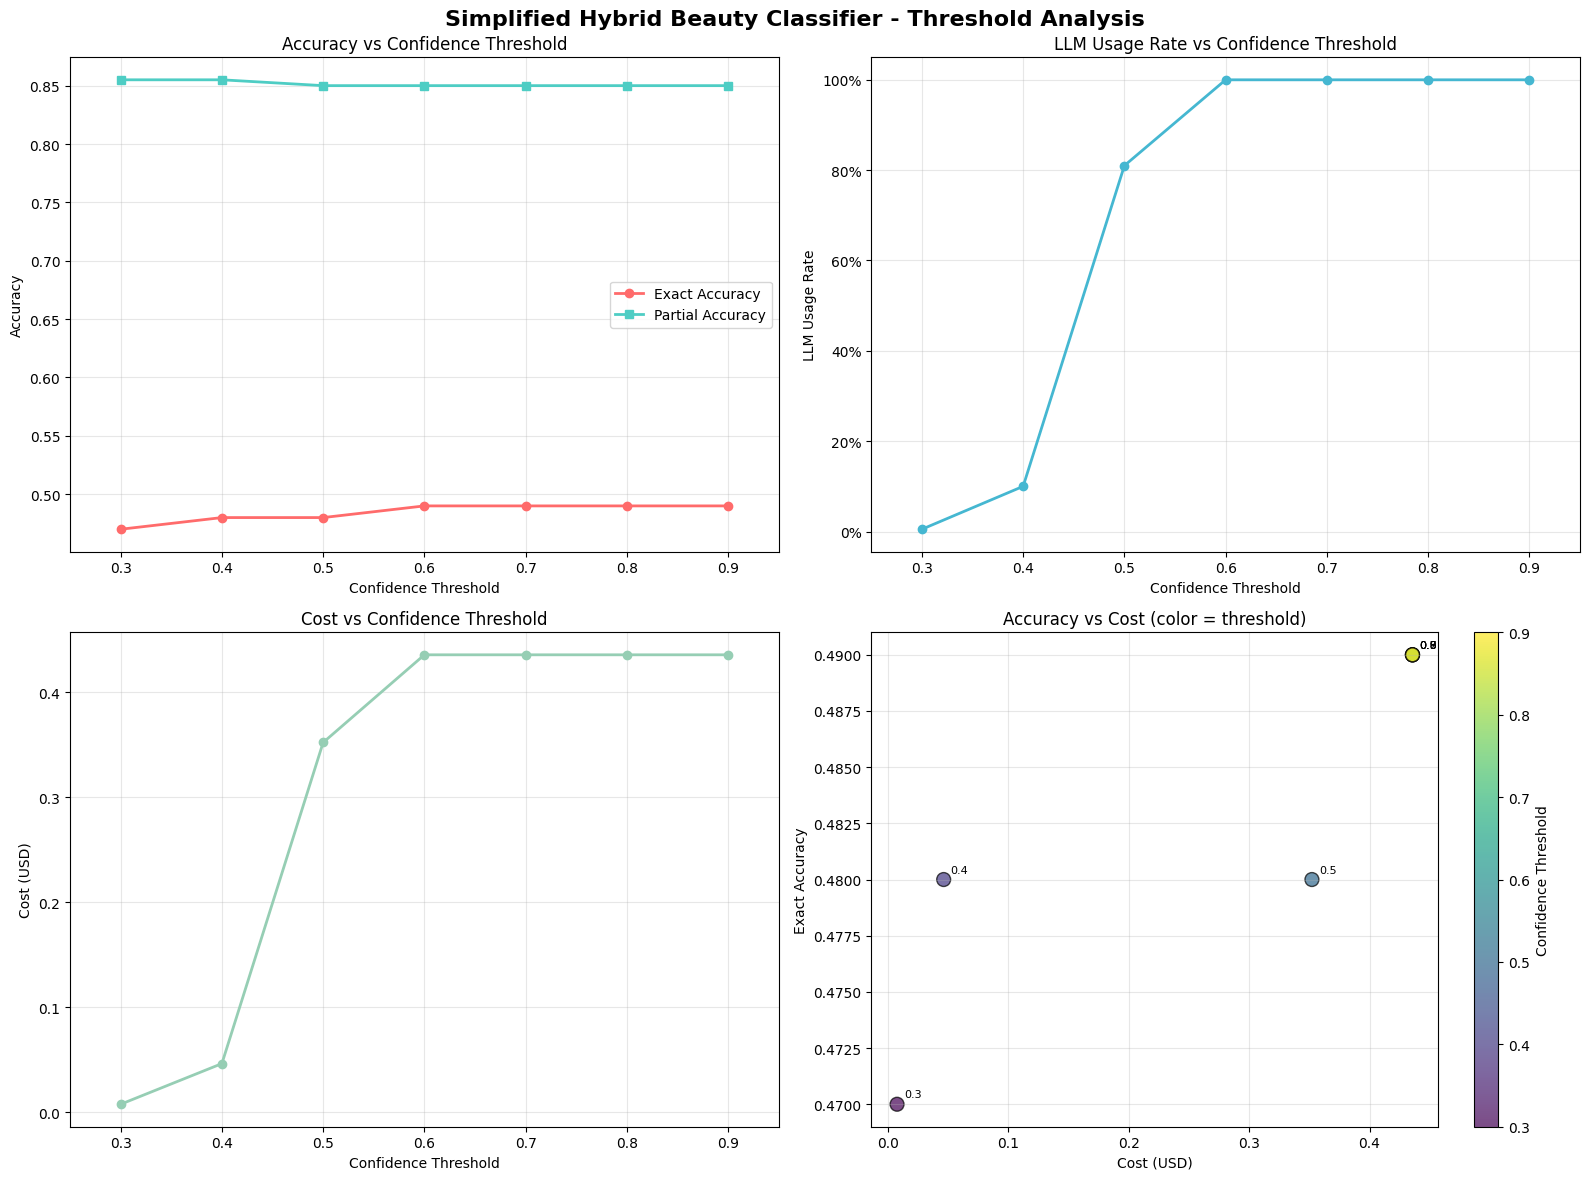

🔍 THRESHOLD ANALYSIS
📊 Threshold Analysis:
   🎯 Best accuracy: 0.6 (0.490)
   💰 Lowest cost: 0.3 ($0.0076)
   ⚖️ Best efficiency: 0.3

💡 RECOMMENDATIONS:
   🎯 For best accuracy: Use threshold 0.6
   💰 For lowest cost: Use threshold 0.3
   ⚖️ For best balance: Use threshold 0.3

📈 TRADE-OFF ANALYSIS:
   Threshold 0.3: 0.470 accuracy, 0.5% LLM usage, $0.0076 cost
   Threshold 0.4: 0.480 accuracy, 10.0% LLM usage, $0.0463 cost
   Threshold 0.5: 0.480 accuracy, 81.0% LLM usage, $0.3522 cost
   Threshold 0.6: 0.490 accuracy, 100.0% LLM usage, $0.4357 cost
   Threshold 0.7: 0.490 accuracy, 100.0% LLM usage, $0.4357 cost
   Threshold 0.8: 0.490 accuracy, 100.0% LLM usage, $0.4357 cost
   Threshold 0.9: 0.490 accuracy, 100.0% LLM usage, $0.4357 cost


In [96]:
# CELL 13: VISUALIZATION AND ANALYSIS
# ============================================================================

def create_threshold_visualizations(threshold_results: dict):
    """Create visualizations for threshold comparison"""
    
    if not threshold_results:
        print("❌ No threshold results to visualize")
        return
    
    # Prepare data
    thresholds = list(threshold_results.keys())
    accuracies = [threshold_results[t]['accuracy'] for t in thresholds]
    partial_accuracies = [threshold_results[t]['partial_accuracy'] for t in thresholds]
    llm_usage_rates = [threshold_results[t]['llm_usage_rate'] for t in thresholds]
    costs = [threshold_results[t]['total_cost'] for t in thresholds]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Simplified Hybrid Beauty Classifier - Threshold Analysis', fontsize=16, fontweight='bold')
    
    # 1. Accuracy vs Threshold
    axes[0, 0].plot(thresholds, accuracies, marker='o', linewidth=2, label='Exact Accuracy', color='#FF6B6B')
    axes[0, 0].plot(thresholds, partial_accuracies, marker='s', linewidth=2, label='Partial Accuracy', color='#4ECDC4')
    axes[0, 0].set_title('Accuracy vs Confidence Threshold')
    axes[0, 0].set_xlabel('Confidence Threshold')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xlim(min(thresholds)-0.05, max(thresholds)+0.05)
    
    # 2. LLM Usage vs Threshold
    axes[0, 1].plot(thresholds, llm_usage_rates, marker='o', linewidth=2, color='#45B7D1')
    axes[0, 1].set_title('LLM Usage Rate vs Confidence Threshold')
    axes[0, 1].set_xlabel('Confidence Threshold')
    axes[0, 1].set_ylabel('LLM Usage Rate')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(min(thresholds)-0.05, max(thresholds)+0.05)
    axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # 3. Cost vs Threshold
    axes[1, 0].plot(thresholds, costs, marker='o', linewidth=2, color='#96CEB4')
    axes[1, 0].set_title('Cost vs Confidence Threshold')
    axes[1, 0].set_xlabel('Confidence Threshold')
    axes[1, 0].set_ylabel('Cost (USD)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(min(thresholds)-0.05, max(thresholds)+0.05)
    
    # 4. Accuracy vs Cost (with threshold as color)
    scatter = axes[1, 1].scatter(costs, accuracies, c=thresholds, s=100, cmap='viridis', alpha=0.7, edgecolors='black')
    axes[1, 1].set_xlabel('Cost (USD)')
    axes[1, 1].set_ylabel('Exact Accuracy')
    axes[1, 1].set_title('Accuracy vs Cost (color = threshold)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add threshold labels to scatter plot
    for i, threshold in enumerate(thresholds):
        axes[1, 1].annotate(f'{threshold}', (costs[i], accuracies[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add colorbar for threshold
    cbar = plt.colorbar(scatter, ax=axes[1, 1])
    cbar.set_label('Confidence Threshold')
    
    plt.tight_layout()
    plt.show()

def analyze_threshold_results(threshold_results: Dict):
    """Analyze threshold results for insights"""
    
    print("🔍 THRESHOLD ANALYSIS")
    print("="*40)
    
    if not threshold_results:
        print("❌ No results to analyze")
        return
    
    # Find optimal thresholds for different criteria
    accuracies = {t: r['accuracy'] for t, r in threshold_results.items()}
    costs = {t: r['total_cost'] for t, r in threshold_results.items()}
    llm_usage = {t: r['llm_usage_rate'] for t, r in threshold_results.items()}
    
    best_accuracy_threshold = max(accuracies, key=accuracies.get)
    lowest_cost_threshold = min(costs, key=costs.get)
    
    print(f"📊 Threshold Analysis:")
    print(f"   🎯 Best accuracy: {best_accuracy_threshold} ({accuracies[best_accuracy_threshold]:.3f})")
    print(f"   💰 Lowest cost: {lowest_cost_threshold} (${costs[lowest_cost_threshold]:.4f})")
    
    # Cost-accuracy efficiency
    efficiency_scores = {}
    for t in threshold_results.keys():
        # Normalize accuracy and inverse cost
        norm_accuracy = accuracies[t]
        norm_inv_cost = 1 / (costs[t] + 0.0001)  # Add small value to avoid division by zero
        efficiency_scores[t] = norm_accuracy * norm_inv_cost
    
    best_efficiency_threshold = max(efficiency_scores, key=efficiency_scores.get)
    print(f"   ⚖️ Best efficiency: {best_efficiency_threshold}")
    
    # Recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    print(f"   🎯 For best accuracy: Use threshold {best_accuracy_threshold}")
    print(f"   💰 For lowest cost: Use threshold {lowest_cost_threshold}")
    print(f"   ⚖️ For best balance: Use threshold {best_efficiency_threshold}")
    
    # Show trade-offs
    print(f"\n📈 TRADE-OFF ANALYSIS:")
    for threshold in sorted(threshold_results.keys()):
        result = threshold_results[threshold]
        print(f"   Threshold {threshold}: {result['accuracy']:.3f} accuracy, "
              f"{result['llm_usage_rate']:.1%} LLM usage, ${result['total_cost']:.4f} cost")

# Create visualizations if threshold comparison results are available
if 'threshold_comparison' in locals() and threshold_comparison:
    print("🎨 Creating threshold visualizations...")
    create_threshold_visualizations(threshold_comparison)
    analyze_threshold_results(threshold_comparison)
else:
    print("📊 No threshold comparison results available for visualization")

In [97]:
# CELL 14: SAVE RESULTS AND FINAL STATS
# ============================================================================

def save_simplified_results(threshold_results: dict = None, batch_results: Dict = None):
    """Save simplified evaluation results to files"""
    
    print("💾 Saving simplified evaluation results...")
    
    # Create results directory
    results_dir = "simplified_results"
    os.makedirs(results_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    try:
        # Save threshold comparison results
        if threshold_results:
            threshold_file = os.path.join(results_dir, f"threshold_comparison_{timestamp}.json")
            with open(threshold_file, 'w') as f:
                json.dump(threshold_results, f, indent=2, default=str)
            print(f"✅ Threshold comparison saved: {threshold_file}")
        
        # Save detailed batch results
        if batch_results:
            # Convert to DataFrame for easier analysis
            results_df = pd.DataFrame(batch_results['detailed_results'])
            batch_file = os.path.join(results_dir, f"batch_results_{timestamp}.csv")
            results_df.to_csv(batch_file, index=False)
            print(f"✅ Batch results saved: {batch_file}")
        
        # Save configuration and stats
        stats = simplified_classifier.get_comprehensive_stats() if 'simplified_classifier' in locals() else {}
        config_data = {
            'timestamp': timestamp,
            'config': asdict(config),
            'stats': stats,
            'test_samples': len(test_df) if 'test_df' in locals() else 0,
            'system_version': 'simplified_hybrid_with_configurable_threshold'
        }
        
        config_file = os.path.join(results_dir, f"config_and_stats_{timestamp}.json")
        with open(config_file, 'w') as f:
            json.dump(config_data, f, indent=2, default=str)
        print(f"✅ Config and stats saved: {config_file}")
        
        print(f"\n📁 All results saved to: {results_dir}/")
        
    except Exception as e:
        print(f"❌ Error saving results: {e}")

# Save results and caches
if 'simplified_classifier' in locals():
    # Save caches
    simplified_classifier.save_all_caches()
    
    # Save evaluation results
    threshold_to_save = threshold_comparison if 'threshold_comparison' in locals() else None
    batch_to_save = simplified_batch_results if 'simplified_batch_results' in locals() else None
    
    save_simplified_results(threshold_to_save, batch_to_save)
    
    print("\n📊 FINAL COMPREHENSIVE STATS:")
    final_stats = simplified_classifier.get_comprehensive_stats()
    
    print(f"\n🔄 HYBRID STATS:")
    for key, value in final_stats['hybrid'].items():
        print(f"   {key}: {value}")
    
    print(f"\n📊 EMBEDDING STATS:")
    for key, value in final_stats['embedding'].items():
        print(f"   {key}: {value}")
    
    print(f"\n🧠 LLM STATS:")
    for key, value in final_stats['llm'].items():
        print(f"   {key}: {value}")
    
    print(f"\n🎯 CURRENT CONFIGURATION:")
    print(f"   Confidence threshold: {config.confidence_threshold}")
    print(f"   Conservative threshold: {config.CONSERVATIVE_THRESHOLD}")
    print(f"   Balanced threshold: {config.BALANCED_THRESHOLD}")
    print(f"   Aggressive threshold: {config.AGGRESSIVE_THRESHOLD}")

print("\n" + "="*60)
print("🎉 SIMPLIFIED HYBRID CLASSIFIER COMPLETE")
print("="*60)
print("✅ Pure hybrid approach with single configurable threshold")
print("💡 Adjust threshold to balance accuracy vs cost")
print("🔧 Use config.set_*_threshold() or classifier.update_threshold()")
print("="*60)

💾 Saved embedding cache: 663 entries
💾 Saved LLM cache: 450 entries
💾 All caches saved
💾 Saving simplified evaluation results...
✅ Threshold comparison saved: simplified_results\threshold_comparison_20250904_115035.json
✅ Batch results saved: simplified_results\batch_results_20250904_115035.csv
✅ Config and stats saved: simplified_results\config_and_stats_20250904_115035.json

📁 All results saved to: simplified_results/

📊 FINAL COMPREHENSIVE STATS:

🔄 HYBRID STATS:
   total_classifications: 1603
   method_usage: {'embedding': 418, 'hybrid': 1185}
   total_cost: 2.588654719999997
   total_time: 196.50981068611145
   llm_usage_rate: 0.7392389270118528
   current_threshold: 0.6
   accuracy_stats: {'correct': 776, 'total': 1603}
   running_accuracy: 0.4840923268870867

📊 EMBEDDING STATS:
   embeddings_created: 200
   cache_hits: 1404
   cache_rate: 87.5%
   searches_performed: 1603
   total_cost: 0.005411769999999996
   categories_indexed: 362

🧠 LLM STATS:
   llm_requests: 200
   cache_h